# [Decliner-SO] Reproduction de l'étude Décliner la science ouverte : de R à Python

Émilien SCHULTZ - PySHS - 18/05/2022 - modifié le 03/06/2022

Célya GRUSON-DANIEL modifié le 21/06/22 (ajout contextualisation initiale)

## 1. Contexte de l'étude « Décliner la science ouverte »

L’étude Décliner la science ouverte (Decliner-SO) a été réalisée dans le cadre de la mission « [Réussir l’appropriation de la science ouverte](https://www.ouvrirlascience.fr/reussir-lappropriation-de-la-science-ouverte/?menu=1) » pour le Comité pour la science ouverte (CoSO). 
Elle constitue une enquête de terrain auprès de professionnel·le·s de la recherche dans diverses disciplines pour :
- mieux appréhender les pratiques associées aux données et leurs évolutions avec la science ouverte ;
- comprendre les facteurs différenciant ces pratiques (discipline, démarche de recherche, etc.)
- apporter un accompagnement adapté aux besoins de différentes communautés de recherche.

L’étude réalisée s’est appuyée sur des méthodes mixtes avec deux premières phases qualitatives comprenant des entretiens (exploratoires, observation des pratiques), des focus group, et une journée d’étude. À la suite, une phase quantitative a été réalisée s’appuyant sur la conception, diffusion et analyse d’un questionnaire auprès des enseignant·e-chercheur·e.s et des personnels de la recherche en France (plus de 400 réponses). L’étude s’est finalisée par le croisement des résultats de ces phases et une démarche design pour faciliter l’appropriation du contenu.


### Résumé synthétique de la méthodologie d’analyse du questionnaire : 

0. Exportation des résultats (.csv) du questionnaire réalisé sur limesurvey.
    - réponses complètes seulement (429 réponses)
1. Simplification/préparation des données
    - sous Libre Office Calc
    - pondération des données pour être représentatif de la répartition des disciplines en ESR
2. Analyse statistique descriptive univariée
    - tris à plat
    - tris croisés
3. Analyse statistique multivariée
    - ACM HCPC séparant deux dimensions (pratiques « open science » et contexte de recherche)

L'analyse a été réalisée par Claire Lemercier (CNRS/CSO-Science-Po) avec l'utilisation de Libre Office Calc pour la préparation des données puis de R pour les analyses statistiques.

## 2. Cadrage du projet de reproduction des résultats

### Objectifs

Dans une démarche de reproductibilité, un projet de reproduction des résultats a été réalisé par Emilien Schultz consistant à : 

- repartir des données brutes et tenter la reproduction de l'ensemble des traitements effectués (structuration, mise en forme des données, analyses statistiques en utilisant Python (analyse initiale en R). 
- s'aider de l'ensemble des contenus produits (fichiers de données bruts et intermédiaires,scripts en R et sa documentation, note méthodologique, rapports et résumés des résultats finaux, graphiques).

Le projet a permis plus largement d'entamer une réflexion sur l'autonomie de la reproduction des traitements et les orientations et pratiques épistémologiques que reflètent l'utilisation de R et de python et des bibliothèques spécialisées développées dans certaines communautés de recherche (FactoMineR par exemple). 

### Synthèse 

De ce projet, il en ressort : 
- une possibilité de reproduire les principaux traitements réalisés avec des itérations nécessaires avec l'équipe projet pour clarifier certains points méthodologiques (travail encore en cours)
- la nécessité de développer de nouvelles fonctions pour être au plus proche des bibliothèques créees sur R faisant ressortir des choix épistémologiques ancrées et (invisibilisés) dans les outils employés par les communautés
- la proposition d'une exploration interactive des données pour faciliter leur analyse au cours du projet 

### Quelques limites :

- Des fonctions/outils spécifiques à R manquent à Python. Cela a conduit à recoder certaines fonctions, mais ce processus n'est pas encore aboutit. Les améliorations principales à faire concernent : 
    - la prise en compte de la pondération des données pour certains traitements, 
    - une différence numérique (minime) entre les résultats R et Python de la fonction catdes
- Des pratiques d'analyse bien que documentées nécessitant un temps important d'appropriation et de redécouverte. 

### Pistes futures pour le projet (travail encore en cours)

- itération supplémentaire entre l'équipe projet "Décliner-SO" et Emilien Schultz pour répondre à quelques questionnements encore en suspens (travail en cours)
- un dialogue au plus long terme avec les équipes de développement des bibliothèques R pour comprendre quelques différences
- une amélioration des modules d'exploration interactive des données

## 3. Démarche générale de reproduction de l'étude

Trois grandes étapes ont été nécessaires :

1. reproduction du recodage pour produire un tableau identique
2. reproduction des analyses statistiques (classification)
3. visualisations et éléments diffusables (travail en cours)

Pour éviter d'accumuler les erreurs, chaque étape repart des données utilisées dans la première étude

- données brutes : `2021_QSO_data-brut.csv`
- données recodées avec pondération : `21-08_QSO2_ponderation.csv`

La note méthodolgique `2022-01_note-methodo-v0.1.pdf` et les scripts R ont été employés pour s'approprier les différents traitements réalisées.

### Quelques remarques

Journal des réflexions :

- identifier les principaux blocages : fonctions R spécifiques + interfaces interactives spécifiques
- script R bien expliqué sur les analyses, moins sur les recodages etc.
 - difficulté de lire la documentation R des fonctions spécifiques à FactoMineR (v test)
 - identifier correctement les dictionnaires de recodage qui a été un peu difficile : important de bien documenter les entités de recodage, les règles qui ont été appliquées, etc
- réflexion sur les widgets en cours -> quelle place donner à l'interactivité ?

Suite à la présentation du 18/05/22

- les widgets semblaient ne pas fonctionner sur le jupyterhub Inno3
- il y a quelques discordances encore dans le traitement des données
- **attention** la coloration des tableaux + widgets n'apparaissent pas sur une forge il faut exécuter le Notebook

## Chargement des bibliothèques utilisées

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

#!pip install prince
import prince
#!pip install pyshs
import pyshs

# Pour la gestion des widgets
import ipywidgets as widgets
from IPython.display import display,clear_output

# Enlever les warnings
import warnings
warnings.filterwarnings('ignore')

# Module spécifique de reproduction des fonctions R en Python
import pyr

## Recodage des données brutes

- bonnes pratiques : utiliser des dictionnaires extérieurs OU des règles claires (possible de combiner les deux)
- à terme, ce bloc peut être mis dans un module dédié
- Constitution de ce bloc est une activité **itérative**, faite de pleins de petits tests & adaptés aux données. Toutes les étapes intermédiaires ne sont pas présentes.
- identification d'une erreur potentielle de recodage (itération prévue d'amélioration en 07/22) : 
   - colonne `oksoutien`, très insatisfait codé en très satisfait
   - idem pour `limite_temps` : ID 1192 codé différemment, d'où vient l'erreur ?
   - erreur dans `fct_autre` : comment cette colonne a-t-elle été constituée ?
   - réduit à 1 de différence pour les disciplines de pondération : d'où vient l'erreur ?

In [2]:
# Chargement des données correctement recodées pour comparaison
data_final = pd.read_csv("../Data/21-08_QSO2_ponderation.csv")

# Chargement des données brutes
data_brut = pd.read_csv("../Data/2021_QSO_data-brut.csv")

# Générer le dictionnaire à compléter pour renommer
#pd.DataFrame(data_brut.columns,
#   columns=["brut"]).to_csv("data/dictionnaire_columns_to_reco.csv")

# Définir les noms de recodage de variable dans un fichier à part
variables = pd.read_csv("../Data/recodage_colonnes.csv")

# Filtrer les variables d'intérêt
f = pd.isnull(variables["variable enlevée dans QSO2"])
data = data_brut[variables[f]["brut"]]
data.columns = list(variables[f]["reco"])

# Recodage des variables
data["sexe"] = data["sexe"] #.fillna("NA")

reco = {"Autres Unix":"LinuxUnix","Linux":"LinuxUnix"}
data["sysOS"] = data["sysOS"].replace(reco)

reco = {'Nous sommes plus de 50 personnes':"11plus", 
        'Nous sommes entre 6 et 10 personnes':"6a10",
        'Nous sommes entre 2 et 5 personnes':"2a5", 
        'Je travaille seul.e':"seule",
        'Nous sommes entre 11 et 20 personnes':"11plus", 
        'Nous sommes entre 21 et 50 personnes':"11plus"}
data["tailleequipe"] = data["tailleequipe"].replace(reco)

reco = {'Plutôt satisfait':"plutotsat", 
        'Plutôt insatisfait':"insatisfait", 
        'Très satisfait':"tressat",
        'Ni satisfait, ni insatisfait':"nini", 
        #'Très insatisfait':"tressat"} ERREUR QUI A ETE FAITE DANS LE CODAGE INITIAL
        'Très insatisfait':"insatisfait"}
data["oksoutien"] = data["oksoutien"].replace(reco)

# Rajout de colonnes spécifiques

# Q224 sur les limites qui est un recodage de colonne (non précisé)
def reco(l):
    col = list(l[["limite1","limite2","limite3","limite4"]])
    if 'Un manque d’habitude de cette pratique dans les communautés de recherche (savoir faire, etc.)' in col:
        return "Oui"
    else:
        return "Non"
    
data["limite_habitude"] = data.apply(reco, axis=1)

def reco(l):
    col = list(l[["limite1","limite2","limite3","limite4"]])
    if 'Une volonté de valoriser le travail effectué avant un partage pour garder un avantage compétitif.' in col:
        return "Oui"
    else:
        return "Non"
data["limite_valo"] = data.apply(reco, axis=1)

def reco(l):
    col = list(l[["limite1","limite2","limite3","limite4"]])
    if 'Un doute sur la capacité de réutilisation des données par d’autres (contextualisation et documentation nécessaire).' in col:
        return "Oui"
    else:
        return "Non"
data["limite_doute"] = data.apply(reco, axis=1)

def reco(l):
    col = list(l[["limite1","limite2","limite3","limite4"]])
    if 'Un temps trop important nécessaire à leur mise à disposition.' in col:
        return "Oui"
    else:
        return "Non"
data["limite_temps"] = data.apply(reco, axis=1)

def reco(l):
    col = list(l[["limite1","limite2","limite3","limite4"]])
    if 'Une peur de mésusage des données par les personnes les réutilisant.' in col:
        return "Oui"
    else:
        return "Non"
data["limite_mesusage"] = data.apply(reco, axis=1)

# Ajout de la variable fct_autre qui prend Oui s'il n'y a pas Oui sur les autres colonnes
data['fct_autre'] = (~data.apply(lambda x : "Oui" in list(x[['fct_perma', 'fct_nonperma', 'fct_IT', 'fct_bib']]),axis=1))

# Codage de colonnes intermédiaires des disciplines et de la pondération
data["dt"] = data["disc_dt"]=="Oui"
data["inf"] = data["disc_inf"]=="Oui"
data["lsh"] = data["disc_lsh"]=="Oui"
data["math"] = data["disc_math"]=="Oui"
data["pluri"] = data["disc_pluri"]=="Oui"
data["vie"] = data["disc_vie"]=="Oui"
data["inge"] = data["disc_inge"]=="Oui"
data["terre"] = data["disc_terre"]=="Oui"
data["matiere"] = data["disc_matiere"]=="Oui"

data["ST"] = (data["inf"] | data["math"] | data["vie"] | data["inge"] |data["matiere"]|data["terre"]|data["pluri"])&(~data["dt"])&(~data["lsh"])
data["LSH"] = (data["lsh"])&~data["dt"]&~data["inf"]&~data["math"]&~data["vie"]&~data["inge"]&~data["terre"]&~data["matiere"]
data["DE"] = (data["dt"])&~data["inf"]&~data["lsh"]&~data["math"]&~data["vie"]&~data["inge"]&~data["terre"]&~data["matiere"]
data["autre"] = ((~data["lsh"])&(~data["dt"])&(~data["inf"])&(~data["math"])&(~data["vie"])&(~data["inge"])&(~data["terre"])&(~data["matiere"]))|(data["ST"] & data["LSH"])|(data["ST"] & data["DE"])|(data["LSH"] & data["DE"])

#    ST = inf or math or vie or inge or matiere or terre or plur) and non dt and non lsh
#    LSH =  (lsh or pluri) and no dt and no inf and no math and no vie and no inge and no terre and no matiere
#    DE = (dt or pluri) and no inf and no lsh and no math and no vie and no inge and no terre and no matiere
#    AUTRE SINON

def reco(l):
    if l["autre"]:
        return "autre"
    if l["ST"]:
        return "ST"
    if l["LSH"]:
        return "LSH"
    if l["DE"]:
        return "DE"
    return "autre"
    
    
    
data["disc_pour_ponde"] = data.apply(reco,axis=1) #petite différence encore A REGLER

# Ajout de la pondération
poids = {"autre":1,"DE":3.4,"LSH":0.6,"ST":1.4}
data["poids"] = data["disc_pour_ponde"].replace(poids)

# Recodage des spécialités

# Création "rétro-ingé" d'un dictionnaire
#t = pd.DataFrame(data.set_index("ID")["specialite"])
#t["recodage_specialite"] = data_final.set_index("ID")["specialite"].sort_index()
#t.set_index("specialite")["recodage_specialite"].dropna().to_csv("./data/recodage_specialites.csv")

# Chargement du dictionnaire
dictionnaire_specialites = {}
for i,j in pd.read_csv("../Data/recodage_specialites.csv").iterrows():
    if pd.notnull(j["specialite"]):
        dictionnaire_specialites[j["specialite"]] = j["recodage_specialite"] 
data["specialite"] = data["specialite"].replace(dictionnaire_specialites)

# Recodage structures

# Création "rétro-ingé" d'un dictionnaire
#t = pd.DataFrame(data.set_index("ID")["structure"])
#t["recodage_structure"] = data_final.set_index("ID")["structure"].sort_index()
#t.set_index("structure")["recodage_structure"].dropna().to_csv("./data/recodage_structure.csv")

# Chargement du dictionnaire
dictionnaire_specialites = {}
for i,j in pd.read_csv("../Data/recodage_structure.csv").iterrows():
    if pd.notnull(j["structure"]):
        dictionnaire_specialites[j["structure"]] = j["recodage_structure"] 
data["structure"] = data["structure"].replace(dictionnaire_specialites)

# Recodage statut
reco = {'Fonctionnaire ou assimilé': "fonct", 'En CDD': "CDD", 'Contrat doctoral': "doct",
        'Autre (précisez en commentaire)': "autre", 'En CDI': "CDI", 
        'Travailleur/travailleuse indépendante': "autre"}
data["statut"] = data["statut"].replace(reco).replace({"ne souhaite pas le dire":None})

# Recodage temps
reco = {'1': "moins", '2': "moins", 'M': "moins", '3': "plus", 'P': "plus"}
liste_var = ['temps_collecte', 'temps_numeriser', 'temps_corpus', 'temps_nettoyer', 'temps_structurer',
          'temps_analyser','temps_modeliser', 'temps_visu', 'temps_qualifier', 'temps_archiver', 
          'temps_qualite', 'temps_disporech', 'temps_com','temps_formation']
for c in liste_var:
    data[c] = data[c].replace(reco)

# Suppression des colonnes "intermédiaites"
data=data.drop(columns=["dt","inf","lsh","math","pluri","vie","inge","autre",
                        "terre","matiere","ST","LSH","DE",
                        "limite1","limite2","limite3","limite4"])

NameError: name 'pd' is not defined

#### Exemple de règles à traduire pour les disciplines de recodage

- “ST” si inclut info et/ou math et/ou vie et/ou ingé et/ou matière et/ou terre et/ou pluri et PAS droit ni LSH

- “LSH” si inclut LSH avec éventuellement pluri, mais aucune des autres catégories

- “DE” si inclut droit avec éventuellement pluri, mais aucune des autres catégories

- “autres” pour 1/ les gens qui ont mis “non” à tout 2/ les gens qui ont mis seulement “pluridisciplinaire” et 3/ les gens qui ont mis des disciplines relevant à la fois de ST et LSH ou ST et DE ou LSH et DE



### Comparaison des codages

Important quand on veut reproduire

-> il y a encore quelques colonnes discordantes à régler

In [492]:
print("format du tableau recodé inital", data_final.shape)
print("format du tableau recodé actuel", data.shape)
print("colonnes absentes du tableau recodé", [i for i in data_final.columns if not i in data.columns])

format du tableau recodé inital (429, 214)
format du tableau recodé actuel (429, 214)
colonnes absentes du tableau recodé []


On peut tester certaines colonnes (même index)

In [493]:
pd.crosstab(data_final.set_index("ID")["envir_labo"],data.set_index("ID")["envir_labo"])

envir_labo,Non,Oui
envir_labo,,
Non,312,0
Oui,0,117


### Vérification de la qualité de la reproductibilité des données

(on calcule le tableau croisé entre le corpus final et le corpus recodé, et on regarde que tout est sur la diagonale)

In [569]:
import numpy as np

for i in data.set_index("ID").columns:
    t = pd.crosstab(data_final.set_index("ID")[i],data.set_index("ID")[i])
    tn = t.to_numpy()
    try:
        if np.count_nonzero(tn - np.diag(np.diagonal(tn)))>0:
            print(t)
    except:
        print("Problème")
        display(t)

oksoutien    insatisfait  nini  plutotsat  tressat
oksoutien                                         
insatisfait           27     0          0        0
nini                   0    50          0        0
plutotsat              0     0         85        0
tressat                8     0          0       34
limite_temps  Non  Oui
limite_temps          
non           228    1
oui             0  200
fct_autre  False  True
fct_autre             
Non          391    12
Oui           19     7
disc_pour_ponde  DE  LSH   ST  autre
disc_pour_ponde                     
DE               21    0    0      0
LSH               0  239    0      0
ST                0    0  126      0
autre             0    0    1     42
poids  0.6  1.0  1.4  3.4
poids                    
0.6    239    0    0    0
1.0      0   42    1    0
1.4      0    0  126    0
3.4      0    0    0   21


## Analyse statistique des données

Utilisation du tableau de données recodées (possible cependant de continuer sur le tableau précédent)

In [153]:
data = pd.read_csv("../Data/21-08_QSO2_ponderation.csv")
data.head()
#list(data.columns)

,ID,envir_labo,envir_clinique,envir_terrain,envir_bibarchives,envir_modele,envir_theoredac,terme_corpus,terme_ressources,terme_valeurs,...,disc_math,disc_pluri,disc_vie,disc_inge,disc_terre,disc_matiere,disc_pour_ponde,poids,specialite,sexe
0,382,Non,Non,Oui,Oui,Oui,Oui,Oui,Oui,Non,...,Non,Non,Non,Non,Non,Non,autre,1.0,autre,Une femme
1,1150,Non,Non,Oui,Oui,Oui,Oui,Oui,Oui,Non,...,Non,Non,Non,Non,Non,Non,autre,1.0,autre,Une femme
2,188,Non,Non,Oui,Oui,Non,Oui,Oui,Non,Non,...,Non,Non,Non,Non,Non,Non,autre,1.0,autre,Autre
3,626,Non,Non,Non,Non,Oui,Oui,Oui,Non,Non,...,Non,Non,Non,Non,Non,Non,autre,1.0,géographie,Un homme
4,320,Non,Non,Oui,Oui,Non,Oui,Oui,Oui,Non,...,Non,Non,Non,Non,Non,Non,autre,1.0,archéologie,Un homme


### Analyses univariées

In [154]:
pyshs.tri_a_plat(data,"envir_labo","poids")

,Effectif redressé,Pourcentage (%)
Non,280.8,64.7
Oui,153.4,35.3
Total,434.2,100.0


In [156]:
pyshs.tri_a_plat(data,"terme_valeurs","poids")

,Effectif redressé,Pourcentage (%)
Non,344.6,79.4
Oui,89.6,20.6
Total,434.2,100.0


Faire les tri à plats d'intérêt

#### Aller vers l'interactivité : exemple

In [161]:
a = list(data.columns)
w = widgets.Dropdown(
    options=a,
    value=a[1],
    description='Variable : ',
    disabled=False,)

def on_change(change):
    if change['type'] == 'change' and change['name'] == 'value':
        clear_output()
        #print("Variable : ",w.value)
        t = pyshs.tri_a_plat(data,w.value,"poids")
        display(t)
        t.to_csv(f"data/{w.value}.csv")
        display(w)

w.observe(on_change)
display(w)

,Effectif redressé,Pourcentage (%)
Non,149.2,34.4
Oui,285.0,65.6
Total,434.2,100.0


Dropdown(description='Variable : ', index=15, options=('ID', 'envir_labo', 'envir_clinique', 'envir_terrain', …

Possibilité de rajouter une sauvegarde automatique dans un fichier, etc.

#### Construction de tri à plats "plus complexes"

Construire des tableaux "à façon".

Par exemple remarquer que les questions ont été codées par "bloc" et que l'on voudrait un tableau par bloc

In [175]:
blocs = set([i.split("_")[0] for i in data.columns if "_" in i])

corpus_tap = {}

for b in blocs:
    col = [i for i in data.columns if b+"_" in i]
    t = {i:pyshs.tri_a_plat(data.fillna("NA"),i,"poids")["Pourcentage (%)"] for i in col}
    t = pd.concat(t,axis=1)    
    corpus_tap[b] = t
corpus_tap.keys()

dict_keys(['quali', 'conserv', 'soutien', 'collab', 'source', 'aide', 'outil', 'forma', 'envir', 'wavec', 'oblig', 'mettredispo', 'terme', 'temps', 'plus', 'log', 'dispo', 'disc', 'produit', 'aidequi', 'fct', 'limite'])

In [176]:
corpus_tap["collab"]

,collab_cahier,collab_bdd,collab_dosspartage,collab_redacpartage,collab_codepartage,collab_wiki,collab_gestionproj,collab_seul
Non,80.7,78.8,21.1,60.0,79.6,86.0,87.0,81.8
Oui,19.3,21.2,78.9,40.0,20.4,14.0,13.0,18.2
Total,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0


#### Production d'une petite visualisation

<AxesSubplot:>

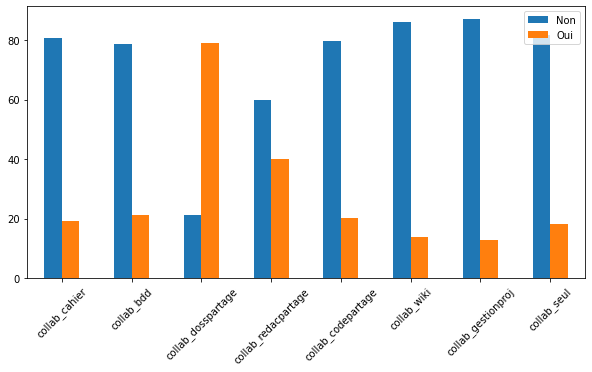

In [182]:
corpus_tap["collab"].drop("Total").T.plot(kind="bar",figsize=(10,5),rot=45)

Visualisation plus finalisées (similaire au rapport, à finaliser si besoin)

In [187]:
values = {i:pyshs.tri_a_plat(data,i,"poids")["Pourcentage (%)"].loc["Oui"] for i in d}

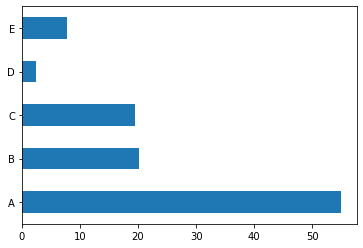

In [193]:
d = ["fct_perma","fct_nonperma","fct_IT","fct_bib","fct_autre"]

# Construction d'un tableau "à façon"
s = pd.Series({i:pyshs.tri_a_plat(data,i,"poids")["Pourcentage (%)"].loc["Oui"] for i in d})

# Base avec Pandas
ax = s.plot(kind="barh")

# Options avec Matplotlib
ax.set_yticklabels(["A","B","C","D","E"])
plt.savefig("fig1.pdf",bbox_inches="tight")

<AxesSubplot:>

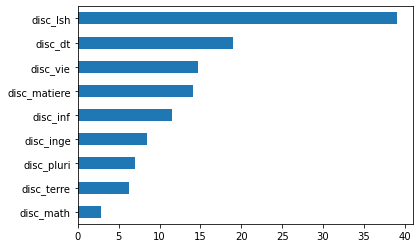

In [194]:
d = [i for i in data.columns if "disc_" in i if i!="disc_pour_ponde"]
s = pd.Series({i:pyshs.tri_a_plat(data,i,"poids")["Pourcentage (%)"].loc["Oui"] for i in d})
s.sort_values().plot(kind="barh")

Text(0.5, 1.0, 'Fonctions des répondants (pondéré)')

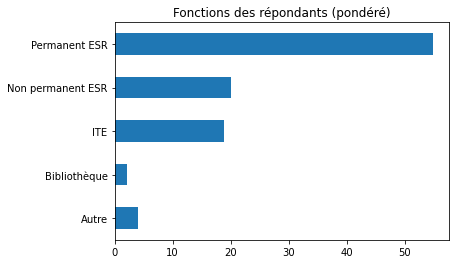

In [431]:
d = ["fct_perma","fct_nonperma","fct_IT","fct_bib","fct_autre","poids"]
data[d].replace({"Oui":1,"Non":0})

def fonction(l):
    if l["fct_perma"]=="Oui":
        return "Permanent ESR"
    if l["fct_nonperma"]=="Oui":
        return "Non permanent ESR"
    if l["fct_IT"]=="Oui":
        return "ITE"
    if l["fct_bib"]=="Oui":
        return "Bibliothèque"
    if l["fct_autre"]:
        return "Autre"
data["fonction"] = data.apply(fonction,axis=1)

pyshs.tri_a_plat(data,"fonction","poids")["Pourcentage (%)"].drop("Total").plot(kind="barh")
plt.title("Fonctions des répondants (pondéré)")

Avec pondération

### Analyse bivariée

L'enjeu est de définir les variables à croiser

Dans R utilisation massive d'une fonction "automatique" catdes -> c'est une philosophie

#### Faire un tableau à la main

In [195]:
tab = pyshs.tableau_croise(data,"reprofam","envir_clinique","poids")
tab.to_csv("data/Tableau.csv")
tab

,Non,Oui,Total
Assez,166.0 (97.3%),4.6 (2.7%),170.6 (100%)
Pas du tout,43.8 (98.6%),0.6 (1.4%),44.4 (100%)
Peu,62.4 (100.0%),0.0 (0.0%),62.4 (100%)
Tout à fait,144.4 (92.1%),12.4 (7.9%),156.8 (100%)
Total,416.6 (95.9%),17.6 (4.1%),434.2 (100%)


In [199]:
pyshs.tableau_croise(data,"reprofam","envir_clinique",
                     "poids",debug=True)

(                       Non          Oui         Total
 Assez        166.0 (97.3%)   4.6 (2.7%)  170.6 (100%)
 Pas du tout   43.8 (98.6%)   0.6 (1.4%)   44.4 (100%)
 Peu          62.4 (100.0%)   0.0 (0.0%)   62.4 (100%)
 Tout à fait  144.4 (92.1%)  12.4 (7.9%)  156.8 (100%)
 Total        416.6 (95.9%)  17.6 (4.1%)  434.2 (100%),
 envir_clinique    Non   Oui    All
 reprofam                          
 Assez           166.0   4.6  170.6
 Pas du tout      43.8   0.6   44.4
 Peu              62.4   0.0   62.4
 Tout à fait     144.4  12.4  156.8
 All             416.6  17.6  434.2,
 envir_clinique    Non  Oui
 reprofam                  
 Assez            97.3  2.7
 Pas du tout      98.6  1.4
 Peu             100.0  0.0
 Tout à fait      92.1  7.9
 All              95.9  4.1)

In [196]:
pd.crosstab(data["reprofam"],data["envir_clinique"])

envir_clinique,Non,Oui
reprofam,,
Assez,156,5
Pas du tout,45,1
Peu,82,0
Tout à fait,130,10


#### Pour l'exploration : un widget

In [200]:
a = list(data.columns) #liste des colonnes
w1 = widgets.Dropdown(options=a, value=a[1], description='Ligne : ', disabled=False,)
w2 = widgets.Dropdown(options=a, value=a[2], description='Colonne : ', disabled=False,)
def on_change(change):
    if change['type'] == 'change' and change['name'] == 'value':
        clear_output()
        tab = pyshs.tableau_croise(data,w1.value,w2.value,"poids")
        display(tab)
        display(w1,w2)
w1.observe(on_change)
w2.observe(on_change)
display(w1,w2)

,Non,Oui,Total
moins,84.0 (42.7%),112.6 (57.3%),196.6 (100%)
plus,9.6 (82.8%),2.0 (17.2%),11.6 (100%)
Total,93.6 (45.0%),114.6 (55.0%),208.2 (100%)


Dropdown(description='Ligne : ', index=38, options=('ID', 'envir_labo', 'envir_clinique', 'envir_terrain', 'en…

Dropdown(description='Colonne : ', index=17, options=('ID', 'envir_labo', 'envir_clinique', 'envir_terrain', '…

#### Plus spécifique pour croiser un ensemble

In [201]:
pyshs.tableau_croise_multiple(data,"sexe",
                [i for i in data.columns if "aide_" in i],"poids")

Autre       Un homme  \
Variable                      Modalités                               
aide_amont (p = 0.014)        Non        28.6 (8.9%)  150.2 (46.9%)   
                              Oui         3.4 (3.0%)   44.4 (39.0%)   
                              Total      32.0 (7.4%)  194.6 (44.8%)   
aide_constitution (p = 0.692) Non        22.6 (7.3%)  141.8 (46.1%)   
                              Oui         9.4 (7.4%)   52.8 (41.7%)   
                              Total      32.0 (7.4%)  194.6 (44.8%)   
aide_traitement (p = 0.276)   Non        26.6 (8.5%)  135.4 (43.3%)   
                              Oui         5.4 (4.4%)   59.2 (48.8%)   
                              Total      32.0 (7.4%)  194.6 (44.8%)   
aide_stockage (p = 0.271)     Non        17.0 (7.6%)  108.2 (48.3%)   
                              Oui        15.0 (7.1%)   86.4 (41.1%)   
                              Total      32.0 (7.4%)  194.6 (44.8%)   
aide_misedispo (p = 0.104)    Non        15.2 (5.9%)  125.8 (48.5%)   
                              Oui        16.8 (9.6%)   68.8 (39.4%)   
                              Total      32.0 (7.4%)  194.6 (44.8%)   
aide_valo (p = 0.075)         Non        25.6 (7.4%)  163.2 (47.5%)   
                              Oui         6.4 (7.1%)   31.4 (34.7%)   
                              Total      32.0 (7.4%)  194.6 (44.8%)   
aide_publi (p = 0.115)        Non        21.6 (7.2%)  145.0 (48.1%)   
                              Oui        10.4 (7.8%)   49.6 (37.4%)   
                              Total      32.0 (7.4%)  194.6 (44.8%)   
aide_nonappl (p = 0.662)      Non        26.6 (7.4%)  157.2 (43.8%)   
                              Oui         5.4 (7.1%)   37.4 (49.5%)   
                              Total      32.0 (7.4%)  194.6 (44.8%)   

                                             Une femme         Total  \
Variable                      Modalités                                
aide_amont (p = 0.014)        Non        141.6 (44.2%)  320.4 (100%)   
                              Oui         66.0 (58.0%)  113.8 (100%)   
                              Total      207.6 (47.8%)  434.2 (100%)   
aide_constitution (p = 0.692) Non        143.2 (46.6%)  307.6 (100%)   
                              Oui         64.4 (50.9%)  126.6 (100%)   
                              Total      207.6 (47.8%)  434.2 (100%)   
aide_traitement (p = 0.276)   Non        150.8 (48.2%)  312.8 (100%)   
                              Oui         56.8 (46.8%)  121.4 (100%)   
                              Total      207.6 (47.8%)  434.2 (100%)   
aide_stockage (p = 0.271)     Non         98.8 (44.1%)  224.0 (100%)   
                              Oui        108.8 (51.8%)  210.2 (100%)   
                              Total      207.6 (47.8%)  434.2 (100%)   
aide_misedispo (p = 0.104)    Non        118.6 (45.7%)  259.6 (100%)   
                              Oui         89.0 (51.0%)  174.6 (100%)   
                              Total      207.6 (47.8%)  434.2 (100%)   
aide_valo (p = 0.075)         Non        155.0 (45.1%)  343.8 (100%)   
                              Oui         52.6 (58.2%)   90.4 (100%)   
                              Total      207.6 (47.8%)  434.2 (100%)   
aide_publi (p = 0.115)        Non        135.0 (44.8%)  301.6 (100%)   
                              Oui         72.6 (54.8%)  132.6 (100%)   
                              Total      207.6 (47.8%)  434.2 (100%)   
aide_nonappl (p = 0.662)      Non        174.8 (48.7%)  358.6 (100%)   
                              Oui         32.8 (43.4%)   75.6 (100%)   
                              Total      207.6 (47.8%)  434.2 (100%)   

                                        Distribution  
Variable                      Modalités               
aide_amont (p = 0.014)        Non              73.8%  
                              Oui              26.2%  
                              Total           100.0%  
aide_constitution (p = 0.692) Non              70.8%

### Analyse d'une variable contre toutes les autres 

**Définir les fonctions en fin de document**

Proposition de recodage d'une partie de  https://rdrr.io/cran/FactoMineR/man/catdes.html

Ce qu'il faut savoir : le v.test est a priori un test assez spécifique, français, implémenté dans FactoMineR

- https://14658237603196614960.googlegroups.com/attach/440e509b29529/Pages%20150-151.pdf?part=0.1&view=1&vt=ANaJVrHl3KCIqqmL5q9gs-4ytVkZxxNPPPsQ7nkW4Xl2bAbeqnPd3ShOoWYryg47013h87O2PP0V9hBrWh82qo-v4umYabgZ10RYQD5xCt5k_Kb-5XptttU
- http://superstatisticienne.fr/typologie-avec-r/
- https://github.com/cran/FactoMineR/blob/master/R/catdes.r


Recoder ce test dépasse la commande ici - mais comme il est central il faut s'y coller ... (version **BETA** à tester + pas optimisée)

Le code est en bas du Notebook

Une autre manière de procéder aurait été de rester à la p.value des tableaux croisés d'indicatrices 
:

- distinguer les variables en modalités
- croiser ces modalités en les filtrant uniquement avec le p (ou le v de cramer)

$$\bowtie\bowtie\bowtie\bowtie\bowtie\bowtie\bowtie\bowtie\bowtie\bowtie\bowtie\bowtie	$$

Tester une variable contre toutes les autres, uniquement les croisements

In [203]:
data.columns[1]

'envir_labo'

In [204]:
pyr.catdes(data,'envir_labo',proba = 0.01, poids="poids")

,p,df
envir_labo,,
source_instru,6.305954e-59,1
disc_pour_ponde,4.860811e-45,3
plus_expe,4.215448e-34,1
terme_mesures,1.246724e-28,1
collab_cahier,4.335243e-28,1
...,...,...
limite_doute,6.493149e-03,1
oblig_comedit,7.844761e-03,1
collab_redacpartage,8.038657e-03,1


Par modalité

In [205]:
var,mod = pyr.catdes(data,"envir_labo",proba = 0.01,modalites=True)
var

,p,df
envir_labo,,
source_instru,8.583897e-56,1
disc_pour_ponde,6.201259e-45,3
disc_lsh,9.645227e-34,1
plus_expe,1.072492e-32,1
terme_mesures,8.894732e-30,1
...,...,...
conserv_servinst,5.981628e-03,1
plus_autom,6.529395e-03,1
conserv_servprive,6.574776e-03,1


In [54]:
mod["envir_labo_Non"][0:15]

,cla/mod,mod/cla,Global,vtest
var dep,,,,
source_instru_Non,93.569132,93.269231,72.494172,15.699211
disc_lsh_Oui,93.207547,79.166667,61.771562,12.079222
plus_expe_Non,83.152174,98.076923,85.780886,11.880456
terme_mesures_Non,89.152542,84.294872,68.764569,11.307675
disc_pour_ponde_LSH,93.305439,71.474359,55.710956,10.708559
disc_matiere_Non,80.519481,99.358974,89.743590,10.694654
collab_cahier_Non,82.240437,96.474359,85.314685,10.638918
terme_corpus_Oui,91.803279,71.794872,56.876457,10.164796
disc_vie_Non,79.319372,97.115385,89.044289,8.719843


## Analyse factorielle

Une fonction spécifique qui n'existe pas en Python : HCPC
https://www.rdocumentation.org/packages/FactoMineR/versions/2.4/topics/HCPC et le code ici https://github.com/cran/FactoMineR/blob/master/R/HCPC.R

- consolidation de la classification avec K mean
- individus les plus représentatifs de chaque classe 

Par ailleurs, à l'heure actuelle avec Python, il n'y a pas d'interface similaire à FactoShiny qui permet d'interagir avec la construction de l'ACM 

- quels sont les besoins ?
- est-ce que l'interactivité permise par les notebooks n'est pas suffisante ?

### Démarche de reproductibilité

- vérifier que la MCA est identique en R et en Python sur le même jeu de données

   - un des enjeux est de bien mettre les NA pour les valeurs nulles, gérées différemment
   - sinon c'est **ok**

- vérifier que la CH donne le même résultat sans la consolidation

   - Même résultat avec AgglomerativeClustering de sklearn
   - Même résultat avec Scipy.clusters.hierarchy linkage,fcluster
   - c'est **ok**
   
- vérifier que le résultat est le même avec la consolidatoin

    - Petite différence après consolidation pour la division en 5
    - Sinon c'est **ok**

In [206]:
# Chargement des données
data = pd.read_csv("../Data/2021-07-22_QSO_pourACM1.csv")
data = data.set_index("ID").sort_index()

# Choix des variables de Claire
c = ["terme_corpus", "terme_ressources", "terme_valeurs", "terme_sources", "terme_materiaux", "terme_mesures", "terme_stat", "terme_jeuxdo", "terme_basedo", "terme_pipeline", "terme_brutes", "terme_nettoyees", 
     "terme_negatives", "reprofam", "quali_tracabilite", "quali_replicabilite", "quali_reproductibilite", "quali_explicabilite", "quali_rechouv", "quali_openschol", "quali_transparence", "partagerestreint", "partagecontrole", 
     "partageligne", "partagelicence", "oblig_comedit", "oblig_comethique", "oblig_financeur", "oblig_partenaire", "oblig_non", "oblig_nonapp", "dispo_amov", "dispo_envoi", "dispo_mail", "dispo_servsecu", "dispo_datapaper", 
     "dispo_supplem", "dispo_site", "dispo_cloudnoninst", "dispo_cloudinst", "dispo_entrepgal", "dispo_entrepdiscip", "dispo_git", "dispo_nsp", "dispo_nonapp", "limite_habitude", "limite_valo", "limite_doute", "limite_temps", 
     "limite_mesusage", "reutilisable", "reutilise", "mettredispo_cahiers", "mettredispo_logiciels", "mettredispo_doc", "mettredispo_metado", "mettredispo_protocole", "mettredispo_blog", "conserv_ordiperso", "conserv_ordiprof", 
     "conserv_externe", "conserv_servint", "conserv_servinst", "conserv_servautre", "conserv_servinfrastr", "conserv_servprive", "conserv_web", "conserv_archivage", "conserv_nonappl", "collab_cahier", "collab_bdd", 
     "collab_dosspartage", "collab_redacpartage", "collab_codepartage", "collab_wiki", "collab_gestionproj", "collab_seul", "connsoutien", "bénésoutien", "oksoutien", "soutien_fi", "soutien_rh", "soutien_infrastr", "soutien_tech", 
     "soutien_forma", "soutien_jur", "soutien_ethique", "soutien_nonapp", "aide_amont", "aide_constitution", "aide_traitement", "aide_stockage", "aide_misedispo", "aide_valo", "aide_publi", "aide_nonappl", "aidequi_speetab", 
     "aidequi_sepecentres", "aidequi_labo", "aidequi_liste", "aidequi_platef", "aidequi_formation", "aidequi_JE", "aidequi_nonappl", "anciennete", "structure", "fct_perma", "fct_nonperma", "fct_IT", "fct_bib", "fct_autre", "statut", 
     "disc_dt", "disc_inf", "disc_lsh", "disc_math", "disc_pluri", "disc_vie", "disc_inge", "disc_terre", "disc_matiere", "specialite", "sexe", "envir_labo", "envir_clinique", "envir_terrain", "envir_bibarchives", "envir_modele", 
     "envir_theoredac", "plus_tech", "plus_expe", "plus_autom", "plus_dorares", "plus_dostandards", "plus_theo", "plus_workflow", "plus_modeli", "plus_support", "temps_collecte", "temps_numeriser", "temps_corpus", "temps_nettoyer", 
     "temps_structurer", "temps_analyser", "temps_modeliser", "temps_visu", "temps_qualifier", "temps_archiver", "temps_qualite", "temps_disporech", "temps_com", "temps_formation", "source_terrain", "source_instru", "source_bddOA",
     "source_bddabo", "source_bddcoll", "source_article", "source_web", "source_archive", "produit_fichierordi", "produit_fichierhteperf", "produit_norme", "produit_script", "produit_logiciel", "produit_notesnum", "produit_notespap", 
     "tailleequipe", "wavec_perman", "wavec_nonperman", "wavec_IT", "wavec_SI", "wavec_bib", "wavec_jur", "wavec_valo", "wavec_scouv", "wavec_manag", "wavec_com", "wavec_intnat", "sysOS", "log_tab", "log_tabsci", "log_bdd", 
     "log_visu", "log_stat", "log_image", "log_datasci", "log_prog", "log_entrep", "log_nonapp", "outil_moi", "outil_equipe", "outil_parten", "outil_employeur", "outil_reso", "outil_liste", "outil_formation", "outil_colloque", 
     "outil_informel", "outil_veille", "outil_nonapp", "forma_equipe", "forma_parten", "forma_atelier", "forma_informel", "forma_mooc", "forma_presentiel", "forma_continue", "forma_tuto", "forma_papier", "forma_nonapp"]

# Création des deux tableaux pour ACM (similaire au script de Claire)
tableau_opendata = data[c[:104]].fillna("NA")
tableau_travail = data[c[104:212]].fillna("NA")

#### Calcul des MCA

Utilisation de la bibliothèque Prince

In [208]:
type(mca1)

prince.mca.MCA

In [209]:
mca1 = prince.MCA(n_components=5)

# Première MCA
Xt_opendata = mca1.fit_transform(tableau_opendata)
labels_opendata = mca1.column_coordinates(tableau_opendata)
print("Open Data ",mca1.explained_inertia_)

# Deuxième MCA
mca2 = prince.MCA(n_components=3)
Xt_travail = mca2.fit_transform(tableau_travail)
labels_travail = mca2.column_coordinates(tableau_travail)
print("Travail ",mca2.explained_inertia_)

Open Data  [0.07148856393023842, 0.03737925468976794, 0.036256122756476626, 0.027032293827353254, 0.025763023170110314]
Travail  [0.13735933097702327, 0.08464502072105207, 0.044652033659721896]


In [215]:
mca1.row_coordinates(tableau_opendata)

,0,1,2,3,4
14,-0.318303,0.181011,0.324637,0.147035,0.003790
15,-0.377251,0.171833,0.083657,0.080042,0.284106
16,-0.454271,0.186156,0.269451,0.157081,0.287402
21,-0.200948,-0.108964,0.274980,-0.110791,0.325373
24,-0.224519,-0.112091,-0.098395,-0.215710,0.075504
...,...,...,...,...,...
1193,-0.094513,-0.269172,0.156658,-0.058933,0.121421
1196,0.053753,-0.425470,0.063317,0.233148,-0.267076
1205,0.127868,0.130383,-0.329110,0.076633,0.122491
1210,0.518276,-0.272761,0.404790,-0.182183,-0.136687


### Classification Hiérarchique CH

Plusieurs manières de procéder

In [216]:
from scipy.cluster.hierarchy import linkage,fcluster

arbre = linkage(Xt_opendata,'ward')
Xt_opendata["clusters"] = fcluster(arbre,5,criterion="maxclust")

arbre = linkage(Xt_travail,'ward')
Xt_travail["clusters"] = fcluster(arbre,3,criterion="maxclust")

Petite visualisation

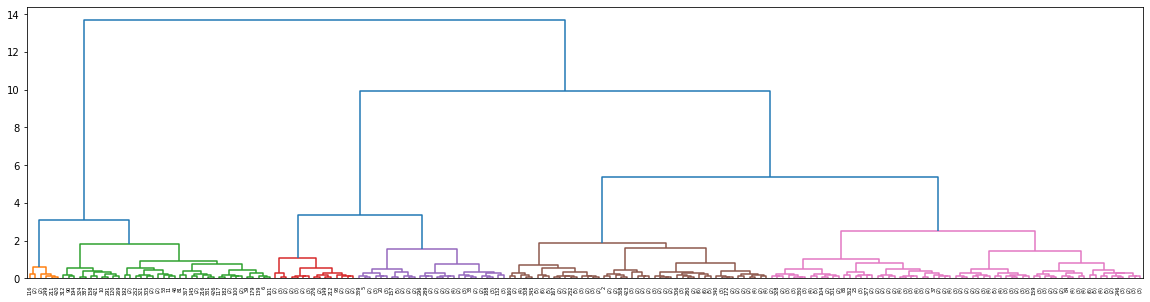

In [217]:
from scipy.cluster.hierarchy import dendrogram

fig,ax=plt.subplots(figsize=(20,5))
t = dendrogram(arbre,distance_sort="ascending",p=200,ax=ax,truncate_mode='lastp',color_threshold=3)

Différentes stratégies pour couper ...

### Effet du choix de la méthode

Pas de différence

In [218]:
from sklearn.cluster import AgglomerativeClustering

comparaison = pd.DataFrame(Xt_opendata["clusters"])

cluster = AgglomerativeClustering(n_clusters=5, affinity='euclidean', linkage='ward')
comparaison["clusters_agglo"] = cluster.fit_predict(Xt_opendata[[0,1,2,3,4]])

pd.crosstab(comparaison["clusters"],comparaison["clusters_agglo"])

clusters_agglo,0,1,2,3,4
clusters,,,,,
1,0,0,0,63,0
2,0,0,128,0,0
3,49,0,0,0,0
4,0,0,0,0,89
5,0,100,0,0,0


### Fonction de consolidation spécifique à R

Recodage de la fonction

In [219]:
Xt_opendata["clusters_consolidated"] = pyr.consolidation(Xt_opendata[[0,1,2,3,4,"clusters"]],"clusters")
Xt_travail["clusters_consolidated"] = pyr.consolidation(Xt_travail[[0,1,2,"clusters"]],"clusters")

#### Test de la superposition

Presque impécable

In [222]:
pd.crosstab(Xt_opendata["clusters_consolidated"],data["classes_opendata"])

classes_opendata,1,2,3,4,5
clusters_consolidated,,,,,
0,0,0,0,0,71
1,0,0,0,119,0
2,46,0,0,1,2
3,1,94,0,0,0
4,0,0,95,0,0


In [223]:
pd.crosstab(Xt_travail["clusters_consolidated"],data["classes_travail"])

classes_travail,1,2,3
clusters_consolidated,,,
0,0,0,52
1,84,0,0
2,0,293,0


Il y a encore une petite différence ... je ne sais pas comment la réduire dans l'état

### Passage à la visualisation

Peut-être là où il y a encore de la marge de progression

#### Données opendata

Out of the box

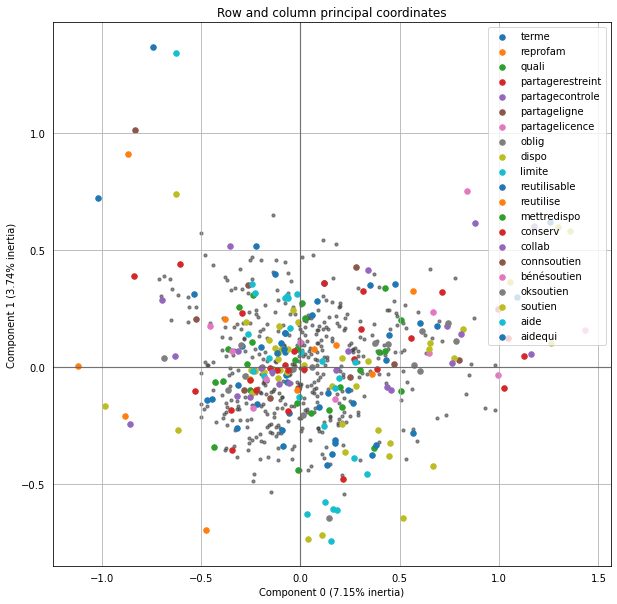

In [15]:
ax = mca1.plot_coordinates(
    X=tableau_opendata,
    ax=None,
    figsize=(10, 10),
    show_row_points=True,
    row_points_size=10,
    show_row_labels=False,
    show_column_points=True,
    column_points_size=30,
    show_column_labels=False,
    legend_n_cols=1)
#ax.get_figure().savefig('mca_coordinates_with_groups.svg')

En modifiant soi même le graphique

(-2.0, 2.0)

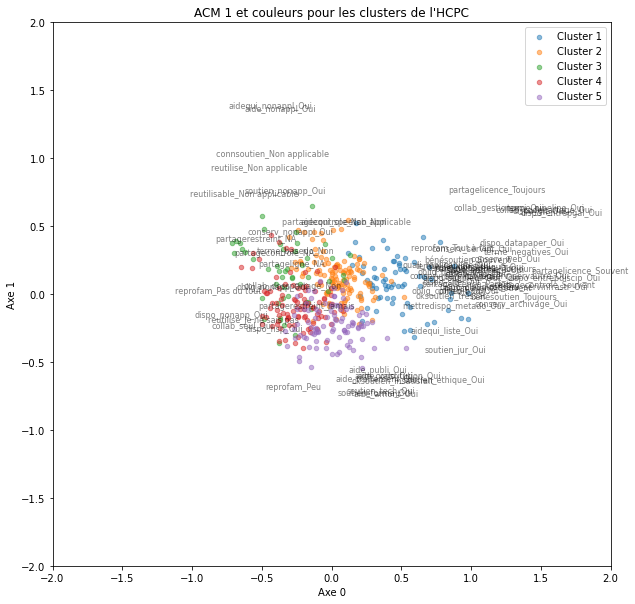

In [226]:
fig,ax = plt.subplots(figsize=(10,10))
for i,g in Xt_opendata.groupby("clusters_consolidated"):
    g.plot(kind="scatter",x=0,y=1,ax=ax,color="C%d"%i,alpha=0.5)

# Affichage des labels
for i,j in labels_opendata.iterrows():
    if abs(j[0])>0.5 or abs(j[1])>0.5:
        ax.text(j[0],j[1],i,fontsize=8,alpha=0.5)

    
plt.legend(["Cluster %d"%i for i in range(1,6)])  
ax.set_title("ACM 1 et couleurs pour les clusters de l'HCPC")
ax.set_xlabel("Axe 0")
ax.set_ylabel("Axe 1")
ax.set_xlim(-2,2)
ax.set_ylim(-2,2)

#### Données travail

In [227]:
Xt_travail["clusters_consolidated"].value_counts()

2    293
1     84
0     52
Name: clusters_consolidated, dtype: int64

(-2.0, 2.0)

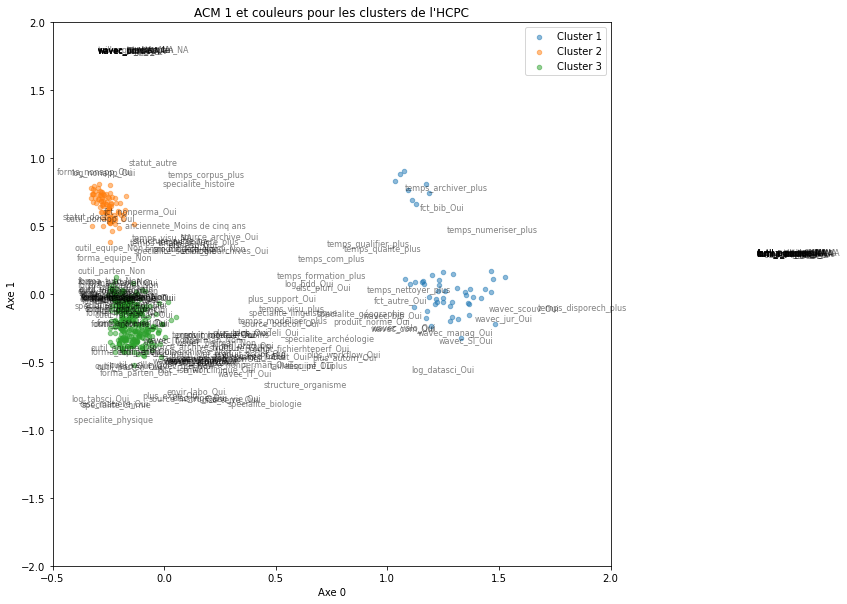

In [228]:
fig,ax = plt.subplots(figsize=(10,10))
for i,g in Xt_travail.groupby("clusters_consolidated"):
    g.plot(kind="scatter",x=0,y=1,ax=ax,color="C%d"%i,alpha=0.5)
    
for i,j in labels_travail.iterrows():
    if abs(j[0])>0.3 or abs(j[1])>0.3:
        ax.text(j[0],j[1],i,fontsize=8,alpha=0.5)

plt.legend(["Cluster %d"%i for i in range(1,4)])  
ax.set_title("ACM 1 et couleurs pour les clusters de l'HCPC")
ax.set_xlabel("Axe 0")
ax.set_ylabel("Axe 1")
ax.set_xlim(-0.5,2)
ax.set_ylim(-2,2)

Souvent : important d'aller dans le détail. Là ça dépend des traditions. Les outils ne sont pas encore complètement implémentés en Python

In [230]:
#mca1.row_coordinates(tableau_opendata)

In [37]:
#mca1.column_coordinates(tableau_opendata)

In [36]:
#mca1.col_masses_

### Description des clusters

Il reste encore quelques éléments à implémenter de CATDES DE R  (ex : The paragons (para) and the more typical individuals of each cluster)

#### Tableaux croisés

In [231]:
pyshs.tableau_croise_multiple(data,"classes_opendata", list(data.columns[5:10]),axis=1)

1           2           3  \
Variable                    Modalités                                       
terme_sources (p = 0.000)   Non        13 (27.7%)  26 (27.7%)  23 (24.2%)   
                            Oui        34 (72.3%)  68 (72.3%)  72 (75.8%)   
                            Total       47 (100%)   94 (100%)   95 (100%)   
terme_materiaux (p = 0.000) Non        32 (68.1%)  36 (38.3%)  50 (52.6%)   
                            Oui        15 (31.9%)  58 (61.7%)  45 (47.4%)   
                            Total       47 (100%)   94 (100%)   95 (100%)   
terme_mesures (p = 0.000)   Non        44 (93.6%)  85 (90.4%)  82 (86.3%)   
                            Oui          3 (6.4%)    9 (9.6%)  13 (13.7%)   
                            Total       47 (100%)   94 (100%)   95 (100%)   
terme_stat (p = 0.002)      Non        37 (78.7%)  56 (59.6%)  46 (48.4%)   
                            Oui        10 (21.3%)  38 (40.4%)  49 (51.6%)   
                            Total       47 (100%)   94 (100%)   95 (100%)   
terme_jeuxdo (p = 0.000)    Non        39 (83.0%)  79 (84.0%)  66 (69.5%)   
                            Oui         8 (17.0%)  15 (16.0%)  29 (30.5%)   
                            Total       47 (100%)   94 (100%)   95 (100%)   

                                                4           5        Total  \
Variable                    Modalités                                        
terme_sources (p = 0.000)   Non        88 (73.3%)  28 (38.4%)  178 (41.5%)   
                            Oui        32 (26.7%)  45 (61.6%)  251 (58.5%)   
                            Total      120 (100%)   73 (100%)   429 (100%)   
terme_materiaux (p = 0.000) Non        94 (78.3%)  48 (65.8%)  260 (60.6%)   
                            Oui        26 (21.7%)  25 (34.2%)  169 (39.4%)   
                            Total      120 (100%)   73 (100%)   429 (100%)   
terme_mesures (p = 0.000)   Non        43 (35.8%)  41 (56.2%)  295 (68.8%)   
                            Oui        77 (64.2%)  32 (43.8%)  134 (31.2%)   
                            Total      120 (100%)   73 (100%)   429 (100%)   
terme_stat (p = 0.002)      Non        65 (54.2%)  32 (43.8%)  236 (55.0%)   
                            Oui        55 (45.8%)  41 (56.2%)  193 (45.0%)   
                            Total      120 (100%)   73 (100%)   429 (100%)   
terme_jeuxdo (p = 0.000)    Non        47 (39.2%)  15 (20.5%)  246 (57.3%)   
                            Oui        73 (60.8%)  58 (79.5%)  183 (42.7%)   
                            Total      120 (100%)   73 (100%)   429 (100%)   

                                      Distribution  
Variable                    Modalités               
terme_sources (p = 0.000)   Non              41.5%  
                            Oui              58.5%  
                            Total           100.0%  
terme_materiaux (p = 0.000) Non              60.6%  
                            Oui              39.4%  
                            Total           100.0%  
terme_mesures (p = 0.000)   Non              68.8%  
                            Oui              31.2%  
                            Total           100.0%  
terme_stat (p = 0.002)      Non              55.0%  
                            Oui              45.0%  
                            Total           100.0%  
terme_jeuxdo (p = 0.000)    Non              57.3%  
                            Oui              42.7%  
                            Total           100.0%

#### Utilisation de catdes "python"

In [ ]:
data["classes_opendata"] = data["classes_opendata"].apply(str)

var,mod = pyr.catdes(data,"classes_opendata",proba = 0.01,
                     modalites=True)

### Mise en forme des heatmaps

- description des classes
- tableau croisé des classes
- contruire les tableaux
- voir avec Pandas pour construire un heatmap adapté

In [233]:
data = pd.read_csv("../Data/2021-07-22_QSO_pourACM1.csv")

#### Description générale

In [234]:
results = catdes(data,"classes_opendata",proba = 0.01)
results

,p,df
classes_opendata,,
dispo_git,5.050805e-38,4
collab_codepartage,1.203805e-36,4
source_instru,6.989069e-32,4
partagelicence,2.891714e-31,16
disc_lsh,9.106435e-31,4
...,...,...
oblig_comethique,3.691038e-03,4
oblig_partenaire,3.847140e-03,4
soutien_forma,4.602505e-03,4


In [235]:
pyshs.tableau_croise_multiple(data,"classes_opendata",list(results.index[0:10]),axis=1)

Attention, les totaux par tableaux sont différents (valeurs manquantes)


1  \
Variable                           Modalités                      
dispo_git (p = 0.000)              Non             45.0 (95.7%)   
                                   Oui               2.0 (4.3%)   
                                   Total              47 (100%)   
collab_codepartage (p = 0.000)     Non               44 (93.6%)   
                                   Oui                 3 (6.4%)   
                                   Total              47 (100%)   
source_instru (p = 0.000)          Non               44 (93.6%)   
                                   Oui                 3 (6.4%)   
                                   Total              47 (100%)   
partagelicence (p = 0.000)         Jamais           3.0 (18.8%)   
                                   Non applicable   5.0 (31.2%)   
                                   Parfois          3.0 (18.8%)   
                                   Souvent           0.0 (0.0%)   
                                   Toujours         5.0 (31.2%)   
                                   Total              16 (100%)   
disc_lsh (p = 0.000)               Non               13 (27.7%)   
                                   Oui               34 (72.3%)   
                                   Total              47 (100%)   
quali_reproductibilite (p = 0.000) Non               36 (76.6%)   
                                   Oui               11 (23.4%)   
                                   Total              47 (100%)   
terme_corpus (p = 0.000)           Non               14 (29.8%)   
                                   Oui               33 (70.2%)   
                                   Total              47 (100%)   
reutilisable (p = 0.000)           Je ne sais pas   9.0 (19.1%)   
                                   Non               4.0 (8.5%)   
                                   Non applicable  17.0 (36.2%)   
                                   Oui             17.0 (36.2%)   
                                   Total              47 (100%)   
partagecontrole (p = 0.000)        Jamais           3.0 (23.1%)   
                                   Non applicable   6.0 (46.2%)   
                                   Parfois          3.0 (23.1%)   
                                   Souvent           0.0 (0.0%)   
                                   Toujours          1.0 (7.7%)   
                                   Total              13 (100%)   
envir_labo (p = 0.000)             Non               41 (87.2%)   
                                   Oui                6 (12.8%)   
                                   Total              47 (100%)   

                                                               2  \
Variable                           Modalités                       
dispo_git (p = 0.000)              Non             94.0 (100.0%)   
                                   Oui                0.0 (0.0%)   
                                   Total               94 (100%)   
collab_codepartage (p = 0.000)     Non                93 (98.9%)   
                                   Oui                  1 (1.1%)   
                                   Total               94 (100%)   
source_instru (p = 0.000)          Non                90 (95.7%)   
                                   Oui                  4 (4.3%)   
                                   Total               94 (100%)   
partagelicence (p = 0.000)         Jamais           86.0 (93.5%)   
                                   Non applicable     2.0 (2.2%)   
                                   Parfois            4.0 (4.3%)   
                                   Souvent            0.0 (0.0%)   
                                   Toujours           0.0 (0.0%)   
                                   Total               92 (100%)   
disc_lsh (p = 0.000)               Non                11 (11.7%)   
                                   Oui                83 (88.3%)   
                                   Total               94 (100%)   
quali_reproductibilit

#### Construction d'une heatmap

- l'enjeu est de prendre un ensemble de variables (notamment celles qui ont la plus forte association)
- construire le tableau de l'écart à la moyenne de la distribution
- faire la heatmap

#### Différentiel de tableau croisé

In [239]:
variables = list(results.index[0:10])
tableau = {}
for v in variables:
    t,b,p = pyshs.tableau_croise(data,"classes_opendata",
                                 v,debug=True)
    t = (p - p.iloc[-1]).drop("All").T
    #if "Non" in t.index:
    #    t = t.drop("Non")
    tableau[v] = t

In [240]:
pd.concat(tableau).style.background_gradient(cmap ='viridis')

#### Travailler à l'échelle des modalités

In [438]:
var = "envir_labo"
table = pd.get_dummies(data.drop(columns=var).copy()).applymap(str)
table[var] = data[var]
results = catdes(table,var,proba = 0.01)
results

,p,df
envir_labo,,
source_instru_Non,5.799181e-55,1
source_instru_Oui,5.799181e-55,1
disc_lsh_Non,3.733274e-33,1
disc_lsh_Oui,3.733274e-33,1
plus_expe_Oui,6.814522e-32,1
...,...,...
oblig_partenaire_Non,6.473521e-03,1
oblig_financeur_Non,6.855556e-03,1
oblig_financeur_Oui,6.855556e-03,1


### Utilisation de catdes (Python version)

In [241]:
data["classes_opendata"] = data["classes_opendata"].apply(str)
var,mod = pyr.catdes(data,"classes_opendata",proba = 0.01,
                     modalites=True)

In [246]:
mod["classes_opendata_4"]

,cla/mod,mod/cla,Global,vtest
var dep,,,,
terme_corpus_Non,56.756757,87.500000,43.123543,11.538667
source_instru_Oui,68.644068,67.500000,27.505828,11.533452
disc_lsh_Non,59.146341,80.833333,38.228438,11.290117
envir_labo_Oui,64.957265,63.333333,27.272727,10.426693
plus_expe_Oui,80.327869,40.833333,14.219114,9.813156
...,...,...,...,...
plus_expe_Non,19.293478,59.166667,85.780886,-9.813156
envir_labo_Non,14.102564,36.666667,72.727273,-10.426693
disc_lsh_Oui,8.679245,19.166667,61.771562,-11.290117


Filtrage par rapport à une condition

In [249]:
table = pd.concat({i:mod[i]["vtest"] for i in mod},
                  axis=1).applymap(lambda x: None if x<1.96 else x)

In [255]:
table.sort_values("classes_opendata_2",ascending=False)

,classes_opendata_1,classes_opendata_2,classes_opendata_3,classes_opendata_4,classes_opendata_5
var dep,,,,,
partagecontrole_Jamais,NaN,9.572093,NaN,NaN,NaN
partagelicence_Jamais,NaN,8.805104,NaN,3.104792,NaN
partageligne_Jamais,NaN,7.325538,NaN,2.425549,NaN
dispo_nonapp_Oui,5.190386,7.225164,NaN,NaN,NaN
oblig_non_Oui,NaN,6.809128,NaN,NaN,NaN
...,...,...,...,...,...
aide_nonappl_Non,NaN,NaN,4.465410,NaN,NaN
log_nonapp_Non,NaN,NaN,NaN,3.760289,2.118910
oblig_nonapp_Non,NaN,NaN,NaN,2.269942,2.320651


In [257]:
table.sort_values("classes_opendata_1",
    ascending=False).style.background_gradient(cmap ='inferno')

,classes_opendata_1,classes_opendata_2,classes_opendata_3,classes_opendata_4,classes_opendata_5
var dep,,,,,
reutilisable_Non applicable,9.643495,nan,nan,nan,nan
reutilise_Non applicable,9.534458,nan,nan,nan,nan
collab_seul_Oui,7.788926,3.567107,nan,nan,nan
collab_dosspartage_Non,7.276746,nan,nan,nan,nan
connsoutien_Non applicable,7.207530,nan,nan,nan,nan
oblig_nonapp_Oui,6.853930,nan,nan,nan,nan
log_nonapp_Oui,6.692182,nan,nan,nan,nan
aide_nonappl_Oui,6.566250,nan,nan,nan,nan
log_tab_Non,5.859164,nan,nan,nan,nan
